In [17]:
import pandas as pd
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [18]:

df = pd.read_csv('D:\data_projects\cookiecats_ab\cookie_cats.csv')

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.2 MB


In [19]:
#Filter the control group and get the historical baseline
control_group = df[df['version'] == 'gate_30']

baseline_retention = control_group['retention_7'].mean()

print(f"Historical baseline retention percentage 7 days : {baseline_retention * 100:.2f}%")

Historical baseline retention percentage 7 days : 19.02%


In [20]:
#Minimum detectabel effect
MDE = 1
target_perc = baseline_retention * 100 + MDE
print(f"target percentage: {target_perc:.2f}")

target percentage: 20.02


In [21]:
#Risk tolerance setting: Setting boundaries for type 1 and type 2 errors.

alpha = 0.05

beta = 0.20


#calculating the minimum required sample size
baseline = 0.1902
target = 0.2002

effect_size = proportion_effectsize(target, baseline)

power_analysis = NormalIndPower()

required_sample = power_analysis.solve_power(
    effect_size = effect_size,
    alpha  = alpha,
    power = 1 - beta,
    alternative = 'two-sided'
)

print(f"required_samplesize: {round(required_sample)}")

required_samplesize: 24657


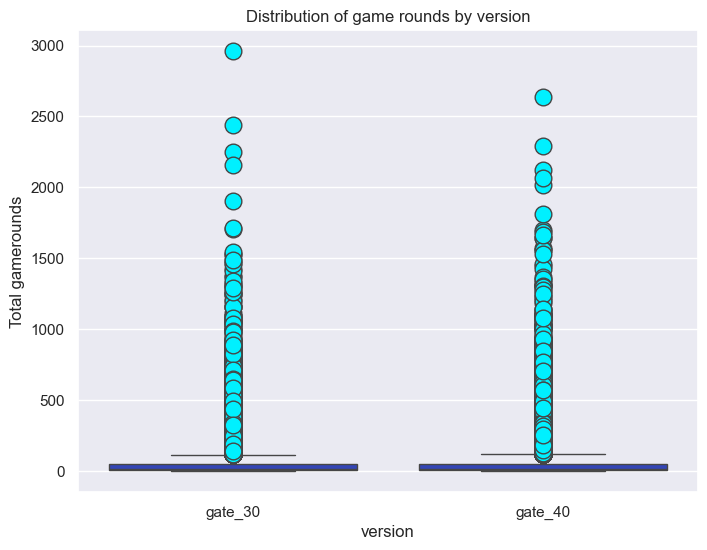

In [33]:
# Outlier detection ysing boxplot
sns.set_theme(style="darkgrid")

plt.figure(figsize=(8,6))
sns.boxplot(
    x='version',
    y='sum_gamerounds',
    data=df,
    color="#1d35cc",
    fliersize=12,
    flierprops={
        "markerfacecolor": "#00f0ff"
    })

plt.title('Distribution of game rounds by version')
plt.xlabel('version')
plt.ylabel('Total gamerounds')
plt.savefig("boxplot_outlier.png", dpi=300, bbox_inches= 'tight')
plt.show()

In [23]:
df.sort_values(by='sum_gamerounds',ascending=False).head(10)

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True
46344,5133952,gate_30,2251,True,True
87007,9640085,gate_30,2156,True,True
36933,4090246,gate_40,2124,True,True
88328,9791599,gate_40,2063,True,True
6536,725080,gate_40,2015,True,True


In [24]:
df = df[df['sum_gamerounds']< 49854]

#checking for duplicates
df['userid'].duplicated().sum() #0

0

In [25]:
#SRM check

observed_gate30 = df[df['version'] == 'gate_30'].shape[0]
observed_gate40 = df[df['version'] == 'gate_40'].shape[0]
observed = [observed_gate30,observed_gate40]
print(f"observed:{observed}")

total_players = sum(observed)
expected = [total_players/2,total_players/2]
print(f"expected:{expected}")

chisq_stat,p_value = stats.chisquare(f_obs=observed, f_exp=expected)

print(f"chi-square statistic: {chisq_stat:.4f}")
print(f"p_value: {p_value:.4f}")

observed:[44699, 45489]
expected:[45094.0, 45094.0]
chi-square statistic: 6.9200
p_value: 0.0085


In [26]:
#A/A baseline evaluation
df[df['sum_gamerounds'] < 30].groupby('version')['sum_gamerounds'].mean()

version
gate_30    9.324205
gate_40    9.203768
Name: sum_gamerounds, dtype: float64

In [27]:
gate_30players = df[(df['version'] == 'gate_30') & (df['sum_gamerounds'] < 30)]['sum_gamerounds']
gate_40players = df[(df['version'] == 'gate_40') & (df['sum_gamerounds'] < 30)]['sum_gamerounds']


t_stat, p_val = stats.ttest_ind(gate_30players,gate_40players, equal_var=False)

print(f"T-stats: {t_stat:.4f}")
print(f"p_value:{p_val:.4f}")

T-stats: 1.8009
p_value:0.0717


In [28]:
#Day 1 retention proportion

retention_day_1 = df.groupby('version')['retention_1'].mean()
print(f"retention after 1 day: {retention_day_1}")

retention after 1 day: version
gate_30    0.448198
gate_40    0.442283
Name: retention_1, dtype: float64


In [29]:
count = df.groupby('version')['retention_1'].sum()
success_gate30 = count['gate_30']
success_gate40 = count['gate_40']
print(f"count of players returned by version: {count}")
print(success_gate30,success_gate40)

count of players returned by version: version
gate_30    20034
gate_40    20119
Name: retention_1, dtype: int64
20034 20119


In [30]:
counts = [success_gate30,success_gate40]
totals = observed
print(totals)

z_test, p_val = proportions_ztest(count=counts, nobs=totals, alternative="two-sided")

print(f"z_test: {z_test:.4f}")
print(f"p_val: {p_val:.4f}")

[44699, 45489]
z_test: 1.7871
p_val: 0.0739


In [31]:
#retention 7

retention_day7 = df.groupby('version')['retention_7'].sum()
print(retention_day7)

success_gate30_day7 = retention_day7['gate_30']
success_gate40_day7 = retention_day7['gate_40']

day7_success = [success_gate30_day7,success_gate40_day7]

z_test, p_val = proportions_ztest(count=day7_success, nobs=totals, alternative= "two-sided")

print(f"z_test: {z_test:.4f}")
print(f"p_val: {p_val:.4f}")

version
gate_30    8501
gate_40    8279
Name: retention_7, dtype: int64
z_test: 3.1574
p_val: 0.0016


In [32]:
#Guardrail metric evaluation

gate_30_rounds = df[df['version'] == 'gate_30']['sum_gamerounds']
gate_40_rounds = df[df['version'] == 'gate_40']['sum_gamerounds']




t_stat, p_val = stats.ttest_ind(gate_30_rounds,gate_40_rounds,equal_var=False)

print(f"Guardrail t_stat:{t_stat:.4f}")
print(f"guardrail p_value: {p_val:.4f}")

Guardrail t_stat:0.0634
guardrail p_value: 0.9495
